# Ejercicio Ridge, Lasso y ElasticNet
Para este ejercicio vas a trabajar con datos de ventas de una empresa que fabrica muebles en España. Esta empresa es una Pyme que demanda conocer de antemano qué ingresos va a tener cada mes, ya que necesita pedir un anticipio a su entidad financiera de cara a poder abastecerse de materia prima al comenzar el mes. Como desconoce cuánto tiene que pedir, tira al alza y acaba pagando muchos intereses. El objetivo es reducir estos gastos.

En las bases de datos de la empresa constan todos los gastos en publicidad y ventas, para cada uno de los meses desde su fundación (hace más de 15 años).

Dado que los presupuestos de marketing se cierran al principio de cada mes, la empresa necesita un modelo predictivo que le anticipe las ventas que conseguirá a final de mes en función de los gastos que realizará en marketing.

Para ello tendrás que utilizar tanto modelos de regresión normales, como regularizados.

1. Carga los datos y realiza un pequeño análisis exploratorio. Mira a ver cómo se relaciona las ventas con el resto de variables.
2. Crea varios modelos y modifica los hiperparámetros necesarios para mejorar el performance del modelo.
3. Interpreta los resultados. Traduce a una fórmula tu mejor modelo (escribir la fórmula simplemente). ¿Cuánto cambian las ventas si aumentamos la inversión en radio un punto más? ¿Y si aumentamos la inversión en TV o periódicos?

## Import libraries 

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Exploratory Data Analysis 

In [24]:
df = pd.read_csv('data/Advertising.csv')
df.set_index('Unnamed: 0', inplace=True)
df.reset_index(drop=True, inplace=True)
df

,TV,radio,newpaper,sales
0,230.1,37.8,6s9.2,22100.0
1,44.5,39.3,45.1,10400.0
2,17.2,45.9,69.3,9300.0
3,151.5,41.3,58.5,18500.0
4,180.8,10.8,58.4,12900.0
...,...,...,...,...
195,38.2,3.7,13.8,7600.0
196,94.2,4.9,8.1,9700.0
197,177.0,9.3,6.4,12800.0
198,283.6,42.0,66.2,25500.0


In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   TV        200 non-null    float64
 1   radio     200 non-null    float64
 2   newpaper  200 non-null    str    
 3   sales     200 non-null    float64
dtypes: float64(3), str(1)
memory usage: 6.4 KB


In [26]:
df['newpaper'] = df['newpaper'].str.replace(r'[a-zA-Z]', '', regex=True).astype(float)
df['newpaper']

0      69.2
1      45.1
2      69.3
3      58.5
4      58.4
       ... 
195    13.8
196     8.1
197     6.4
198    66.2
199     8.7
Name: newpaper, Length: 200, dtype: float64

In [27]:
df.describe()

,TV,radio,newpaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14022.500000
std,85.854236,14.846809,21.778621,5217.456566
min,0.700000,0.000000,0.300000,1600.000000
25%,74.375000,9.975000,12.750000,10375.000000
50%,149.750000,22.900000,25.750000,12900.000000
75%,218.825000,36.525000,45.100000,17400.000000
max,296.400000,49.600000,114.000000,27000.000000


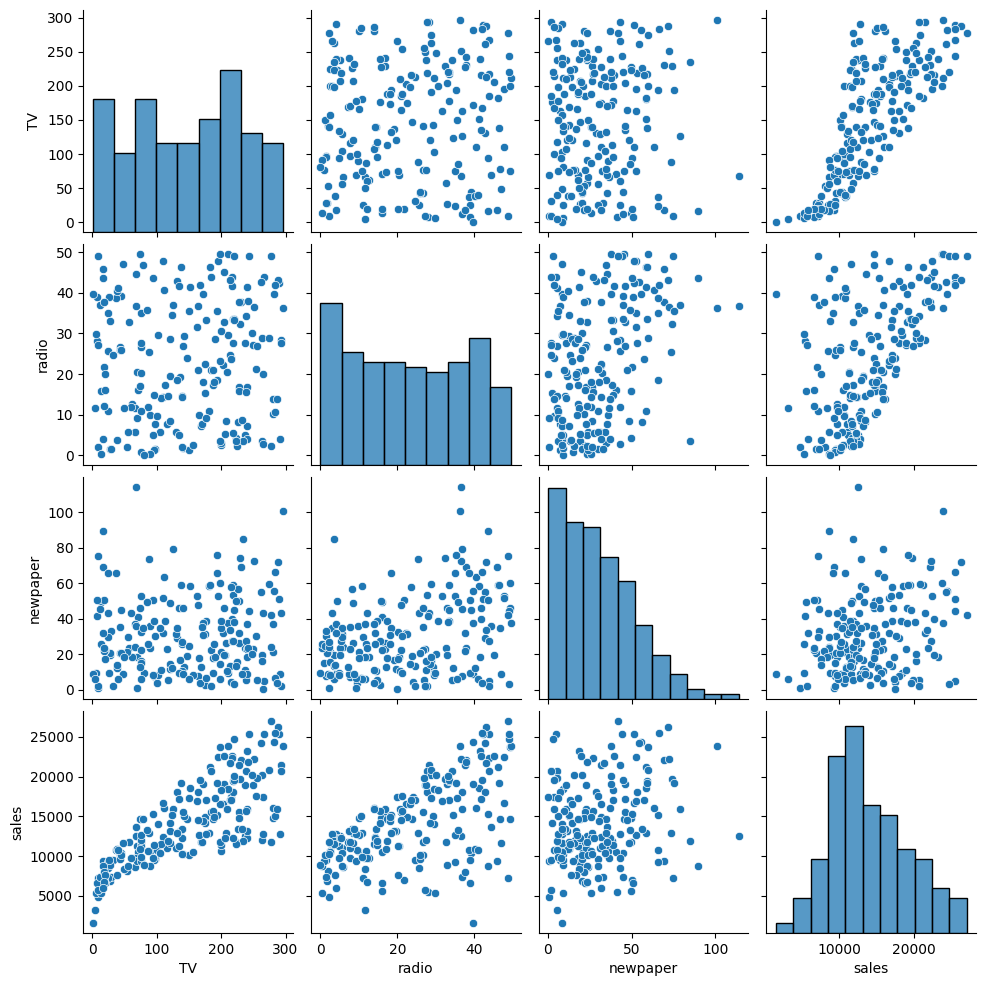

In [28]:
sns.pairplot(df);

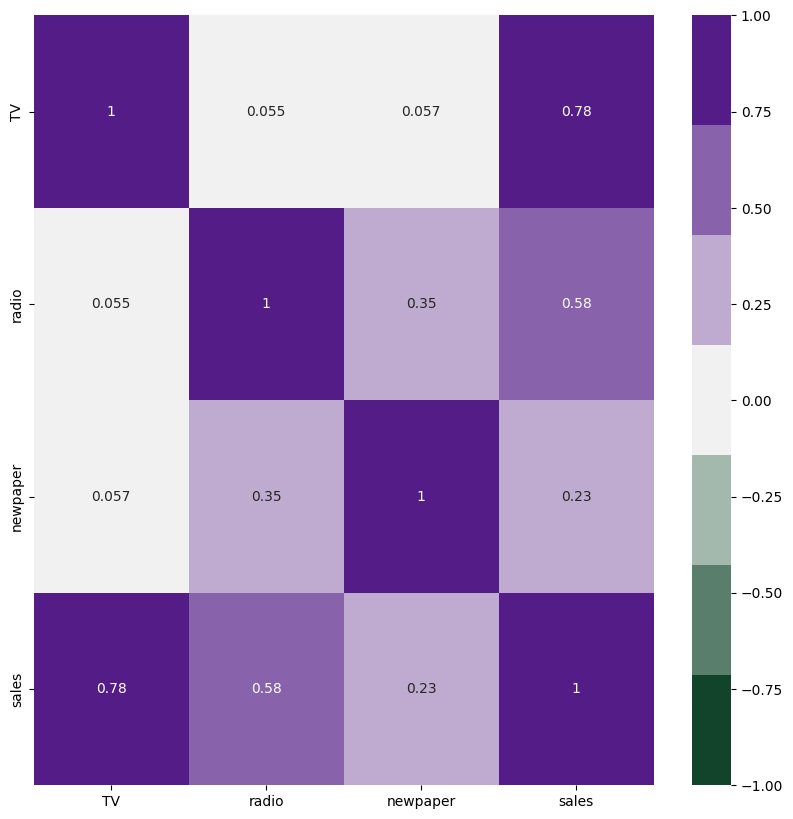

In [29]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(),
           vmin=-1,
           vmax=1,
           cmap=sns.diverging_palette(145, 280, s=85, l=25, n=7),
           annot=True);

## Modelado

In [30]:
X = df[['TV', 'radio', 'newpaper']]
y = df['sales']

In [31]:
#Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
#escalado
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [34]:
#RL simple
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr_train = lr.predict(X_train_scaled)
y_pred_lr_test  = lr.predict(X_test_scaled)

In [35]:
#Ridge
ridge = Ridge(alpha=0.8)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge_train = ridge.predict(X_train_scaled)
y_pred_ridge_test = ridge.predict(X_test_scaled)

In [36]:
#Lasso
lasso = Lasso(alpha=0.8)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso_train = lasso.predict(X_train_scaled)
y_pred_lasso_test = lasso.predict(X_test_scaled)

In [ ]:
# def print_metrics(name, y_train, y_pred_train, y_test, y_pred_test):
#     print(f"\n=== {name} ===")
#     print("Train MAE:", mean_absolute_error(y_train, y_pred_train))
#     print("Test  MAE:", mean_absolute_error(y_test, y_pred_test))

#     print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_train)))
#     print("Test  RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_test)))

#     print("Train R2:", r2_score(y_train, y_pred_train))
#     print("Test  R2:", r2_score(y_test, y_pred_test))

# # MÉTRICAS PARA CADA MODELO
# print_metrics("Linear Regression", y_train, y_pred_lr_train, y_test, y_pred_lr_test)
# print_metrics("Ridge", y_train, y_pred_ridge_train, y_test, y_pred_ridge_test)
# print_metrics("Lasso", y_train, y_pred_lasso_train, y_test, y_pred_lasso_test)



=== Linear Regression ===
Train MAE: 1198.4678961500133
Test  MAE: 1460.7567168117607
Train RMSE: 1644.7277656443375
Test  RMSE: 1781.5996615334514
Train R2: 0.8957008271017817
Test  R2: 0.8994380241009119

=== Ridge ===
Train MAE: 1198.9757054394138
Test  MAE: 1463.5988459612079
Train RMSE: 1644.8940785758657
Test  RMSE: 1786.0625521835043
Train R2: 0.8956797328166584
Test  R2: 0.8989335794403243

=== Lasso ===
Train MAE: 1198.4426539230924
Test  MAE: 1460.612163214701
Train RMSE: 1644.7282195246946
Test  RMSE: 1781.5896829883925
Train R2: 0.8957007695368115
Test  R2: 0.8994391505710378


In [38]:
# --- Evaluación ---
def evaluate_model(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {name} ---")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R2:   {r2:.4f}\n")
    return rmse, r2

results = {}
results['Linear'] = evaluate_model("Linear Regression", y_test, y_pred_lr_test)
results['Ridge'] = evaluate_model("Ridge Regression", y_test, y_pred_ridge_test)
results['Lasso'] = evaluate_model("Lasso Regression", y_test, y_pred_lasso_test)

# Ver coeficientes
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Linear': lr.coef_,
    'Ridge': ridge.coef_,
    'Lasso': lasso.coef_
})
print("Coeficientes del modelo:")
print(coef_df)

--- Linear Regression ---
RMSE: 1781.5997
MAE:  1460.7567
R2:   0.8994

--- Ridge Regression ---
RMSE: 1786.0626
MAE:  1463.5988
R2:   0.8989

--- Lasso Regression ---
RMSE: 1781.5897
MAE:  1460.6122
R2:   0.8994

Coeficientes del modelo:
    Feature       Linear        Ridge        Lasso
0        TV  3764.196175  3746.171872  3763.432643
1     radio  2792.306650  2777.086734  2791.782812
2  newpaper    55.975514    61.916375    55.393374


### Modelos Polinómicos

In [40]:
poly = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

lr_poly = LinearRegression()
lr_poly.fit(X_train_poly, y_train)
y_pred_poly = lr_poly.predict(X_test_poly)

print("--- Polinomio ---")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_poly)):.4f}")
print(f"R2:   {r2_score(y_test, y_pred_poly):.4f}")

--- Polinomio ---
RMSE: 542.7416
R2:   0.9907


## Resultados

In [ ]:
# Interpretación de resultados
print("INTERPRETACIÓN DE RESULTADOS")
print("="*30)

# 1. ¿Cuál es el mejor modelo?
# Generalmente, si hay multicolinealidad o ruido, Ridge o Lasso funcionan mejor que Lineal simple.
# Si Newspaper no es relevante, Lasso pondrá su coeficiente cerca de 0.

best_model_name = min(results, key=lambda k: results[k][0]) # El que tenga menor RMSE
print(f"El mejor modelo según RMSE es: {best_model_name}")

# 2. Fórmula del mejor modelo (usaremos los coeficientes escalados o inversos si quieres la fórmula real)
# Para simplificar, usaremos los coeficientes del modelo elegido sobre los datos escalados.
# Nota: Para obtener la fórmula "real" sin escalar, habría que deshacer la transformación de StandardScaler.
# Aquí mostramos la importancia relativa.

if best_model_name == 'Ridge':
    model_used = ridge
elif best_model_name == 'Lasso':
    model_used = lasso
else:
    model_used = lr

intercept = model_used.intercept_
coefs = model_used.coef_

print(f"\nFórmula aproximada (con datos escalados):")
print(f"Ventas = {intercept:.4f} + ({coefs[0]:.4f} * TV) + ({coefs[1]:.4f} * Radio) + ({coefs[2]:.4f} * Newspaper)")

# 3. Respuesta a las preguntas específicas:
print("\nAnálisis de impacto (basado en coeficientes escalados):")
print("- Un aumento de 1 unidad estandarizada en TV cambia las ventas en:", coefs[0])
print("- Un aumento de 1 unidad estandarizada en Radio cambia las ventas en:", coefs[1])
print("- Un aumento de 1 unidad estandarizada en Newspaper cambia las ventas en:", coefs[2])

# Observación clave sobre Lasso:
if abs(lasso.coef_[2]) < 0.1: # Umbral arbitrario para considerar "cero"
    print("\nNOTA IMPORTANTE: El modelo Lasso ha reducido el coeficiente de 'Newspaper' casi a cero.")
    print("Esto indica que gastar en periódicos NO tiene una relación significativa con las ventas")
    print("una vez que controlamos por TV y Radio. La empresa debería dejar de invertir en periódicos.")
else:
    print("\nTodas las variables parecen tener algún impacto significativo.")

INTERPRETACIÓN DE RESULTADOS
El mejor modelo según RMSE es: Lasso

Fórmula aproximada (con datos escalados):
Ventas = 14100.0000 + (3763.4326 * TV) + (2791.7828 * Radio) + (55.3934 * Newspaper)

Análisis de impacto (basado en coeficientes escalados):
- Un aumento de 1 unidad estandarizada en TV cambia las ventas en: 3763.4326427597334
- Un aumento de 1 unidad estandarizada en Radio cambia las ventas en: 2791.782812277299
- Un aumento de 1 unidad estandarizada en Newspaper cambia las ventas en: 55.39337407345174

Todas las variables parecen tener algún impacto significativo.
